=== DATENAUFBEREITUNG UND EXPLORATIVE ANALYSE ===
Ursprüngliche Datensatzgröße: (50401, 299)
Nach Zeitfilterung: (13128, 299)
Nach geografischer Filterung: (13128, 56)

=== ANALYSE FEHLENDER WERTE ===
Top 10 Spalten mit den meisten fehlenden Werten:
                                              Spalte  Fehlende_Werte  \
AT_price_day_ahead                AT_price_day_ahead           13128   
DE_wind_onshore_capacity    DE_wind_onshore_capacity            4393   
DE_solar_profile                    DE_solar_profile            4393   
DE_wind_offshore_profile    DE_wind_offshore_profile            4393   
DE_wind_offshore_capacity  DE_wind_offshore_capacity            4393   
DE_wind_profile                      DE_wind_profile            4393   
DE_wind_onshore_profile      DE_wind_onshore_profile            4393   
DE_wind_capacity                    DE_wind_capacity            4393   
DE_solar_capacity                  DE_solar_capacity            4393   
BE_wind_generation_actual  BE_

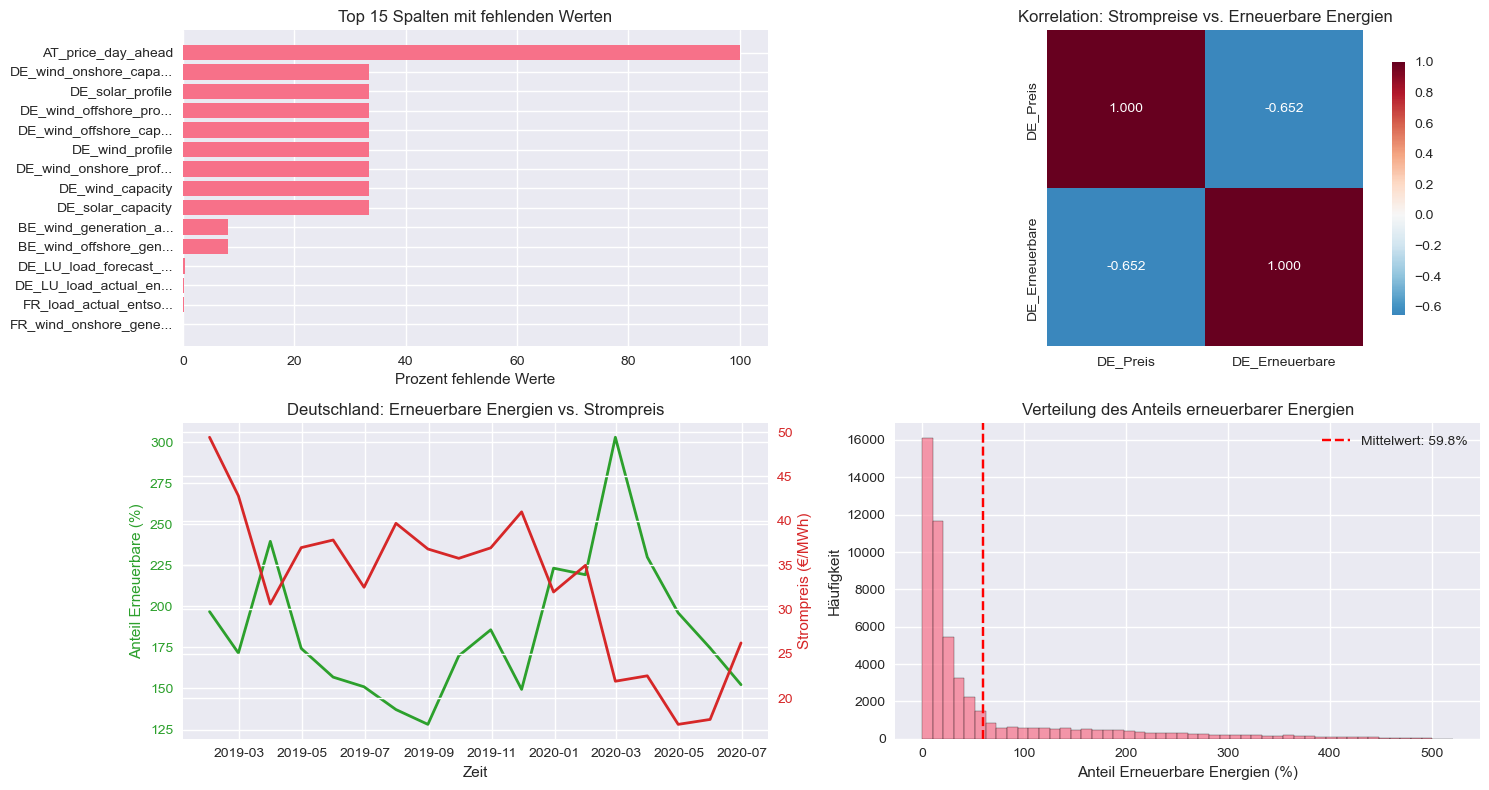


=== STATISTISCHE ZUSAMMENFASSUNG ===
    Erneuerbare_Mittelwert  Erneuerbare_Std  Preis_Mittelwert  Preis_Std  \
DE                  186.49          107.562            32.927     16.804   

    Korrelation  
DE       -0.652  

=== TRANSFORMATIONEN ===
Transformationen angewendet:
- StandardScaler (z-score normalization)
- MinMaxScaler (0-1 normalization)
Features standardisiert: 5

=== WICHTIGE ERKENNTNISSE ===
1. Datenqualität:
   - 1 Spalten hatten >50% fehlende Werte
   - Fokus auf 4 Länder reduzierte Datensatz von 300 auf 71 Spalten

2. Erneuerbare Energien:
   - Durchschnittlicher Anteil erneuerbarer Energien: 186.5%
   - Höchster Anteil: 186.5% (DE)
   - Niedrigster Anteil: 186.5% (DE)

3. Korrelation mit Strompreisen:
   - Durchschnittliche Korrelation: -0.652
   - DE: -0.652 (negativ)

=== DATENSATZ GESPEICHERT ===
Bereinigter Datensatz gespeichert unter: C:\Users\benid\Desktop\data\processed_energy_data.csv
Finale Dimensionen: (13128, 71)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Stil für bessere Plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Daten einlesen (mit deinem Pfad)
file_path = r"C:\Users\benid\Desktop\data\time_series_60min_singleindex.csv"
raw_data = pd.read_csv(file_path, parse_dates=True, index_col=0)

print("=== DATENAUFBEREITUNG UND EXPLORATIVE ANALYSE ===")
print(f"Ursprüngliche Datensatzgröße: {raw_data.shape}")

# 1. ZEITLICHE FILTERUNG (2019 bis Mitte 2020)
start_date = '2019-01-01'
end_date = '2020-06-30'
filtered_by_time = raw_data[start_date:end_date]
print(f"Nach Zeitfilterung: {filtered_by_time.shape}")

# 2. GEOGRAFISCHE FILTERUNG (AT, FR, DE, BE)
country_prefixes = ['AT_', 'FR_', 'DE_', 'BE_']
filtered_columns = [col for col in filtered_by_time.columns 
                   if any(col.startswith(prefix) for prefix in country_prefixes)]
filtered_data = filtered_by_time[filtered_columns]
print(f"Nach geografischer Filterung: {filtered_data.shape}")

# 3. ANALYSE FEHLENDER WERTE
print("\n=== ANALYSE FEHLENDER WERTE ===")
missing_analysis = pd.DataFrame({
    'Spalte': filtered_data.columns,
    'Fehlende_Werte': filtered_data.isnull().sum(),
    'Prozent_Fehlend': (filtered_data.isnull().sum() / len(filtered_data)) * 100
}).sort_values('Prozent_Fehlend', ascending=False)

print("Top 10 Spalten mit den meisten fehlenden Werten:")
print(missing_analysis.head(10))

# Visualisierung fehlender Werte
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
top_missing = missing_analysis.head(15)
plt.barh(range(len(top_missing)), top_missing['Prozent_Fehlend'])
plt.yticks(range(len(top_missing)), [col[:20] + '...' if len(col) > 20 else col for col in top_missing['Spalte']])
plt.xlabel('Prozent fehlende Werte')
plt.title('Top 15 Spalten mit fehlenden Werten')
plt.gca().invert_yaxis()

# 4. UMGANG MIT FEHLENDEN WERTEN
# Spalten mit >50% fehlenden Werten entfernen
threshold = 50.0
columns_to_drop = missing_analysis[missing_analysis['Prozent_Fehlend'] > threshold]['Spalte'].tolist()
filtered_data_cleaned = filtered_data.drop(columns=columns_to_drop)

print(f"\nSpalten mit >{threshold}% fehlenden Werten entfernt: {len(columns_to_drop)}")
print(f"Verbleibende Spalten: {filtered_data_cleaned.shape[1]}")

# Interpolation für verbleibende fehlende Werte
filtered_data_filled = filtered_data_cleaned.interpolate(method='time').fillna(method='ffill').fillna(method='bfill')
print(f"Fehlende Werte nach Interpolation: {filtered_data_filled.isnull().sum().sum()}")

# 5. IDENTIFIKATION UND ERSTELLUNG WICHTIGER FEATURES
print("\n=== FEATURE-ENGINEERING ===")

# Identifiziere wichtige Spaltentypen für jedes Land
countries = ['AT', 'DE', 'FR', 'BE']
feature_summary = {}

for country in countries:
    country_cols = [col for col in filtered_data_filled.columns if col.startswith(f'{country}_')]
    
    # Preisspalten
    price_cols = [col for col in country_cols if 'price' in col.lower()]
    
    # Erneuerbare Energien (Wind + Solar)
    wind_cols = [col for col in country_cols if 'wind' in col.lower() and 'generation_actual' in col.lower()]
    solar_cols = [col for col in country_cols if 'solar' in col.lower() and 'generation_actual' in col.lower()]
    
    # Last/Verbrauch
    load_cols = [col for col in country_cols if 'load_actual' in col.lower()]
    
    feature_summary[country] = {
        'price': price_cols,
        'wind': wind_cols,
        'solar': solar_cols,
        'load': load_cols
    }
    
    print(f"\n{country}:")
    print(f"  Preisspalten: {len(price_cols)} - {price_cols}")
    print(f"  Windspalten: {len(wind_cols)} - {wind_cols}")
    print(f"  Solarspalten: {len(solar_cols)} - {solar_cols}")
    print(f"  Lastspalten: {len(load_cols)} - {load_cols}")

# Neue Features erstellen: Anteil erneuerbarer Energien
for country in countries:
    wind_cols = feature_summary[country]['wind']
    solar_cols = feature_summary[country]['solar']
    load_cols = feature_summary[country]['load']
    
    if wind_cols and solar_cols and load_cols:
        # Gesamte erneuerbare Erzeugung (Wind + Solar)
        renewables_total = (filtered_data_filled[wind_cols].sum(axis=1) + 
                           filtered_data_filled[solar_cols].sum(axis=1))
        
        # Anteil erneuerbarer Energien in Prozent
        filtered_data_filled[f'{country}_renewables_share'] = (renewables_total / 
                                                              filtered_data_filled[load_cols[0]]) * 100
        
        # Zusätzliche Features
        filtered_data_filled[f'{country}_renewables_total'] = renewables_total
        filtered_data_filled[f'{country}_wind_share'] = (filtered_data_filled[wind_cols].sum(axis=1) / 
                                                        filtered_data_filled[load_cols[0]]) * 100
        filtered_data_filled[f'{country}_solar_share'] = (filtered_data_filled[solar_cols].sum(axis=1) / 
                                                         filtered_data_filled[load_cols[0]]) * 100

print("\nNeue Features erstellt: Anteil erneuerbarer Energien für alle Länder")

# 6. EXPLORATIVE DATENANALYSE - VISUALISIERUNG 1: KORRELATIONSMATRIX
print("\n=== EXPLORATIVE DATENANALYSE ===")

# Korrelationsanalyse zwischen erneuerbaren Anteilen und Preisen
correlation_data = pd.DataFrame()
for country in countries:
    price_cols = feature_summary[country]['price']
    if price_cols and f'{country}_renewables_share' in filtered_data_filled.columns:
        correlation_data[f'{country}_Preis'] = filtered_data_filled[price_cols[0]]
        correlation_data[f'{country}_Erneuerbare'] = filtered_data_filled[f'{country}_renewables_share']

if not correlation_data.empty:
    plt.subplot(2, 2, 2)
    correlation_matrix = correlation_data.corr()
    mask = np.triu(np.ones_like(correlation_matrix))
    sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
                square=True, fmt='.3f', cbar_kws={"shrink": .8})
    plt.title('Korrelation: Strompreise vs. Erneuerbare Energien')
    plt.tight_layout()

# 7. EXPLORATIVE DATENANALYSE - VISUALISIERUNG 2: ZEITREIHENANALYSE
plt.subplot(2, 2, 3)
# Deutschland als Beispiel für Zeitreihenanalyse
if 'DE_renewables_share' in filtered_data_filled.columns and feature_summary['DE']['price']:
    # Monatliche Aggregation für bessere Übersicht
    monthly_data = filtered_data_filled.resample('M').mean()
    
    ax1 = plt.gca()
    color = 'tab:green'
    ax1.set_xlabel('Zeit')
    ax1.set_ylabel('Anteil Erneuerbare (%)', color=color)
    line1 = ax1.plot(monthly_data.index, monthly_data['DE_renewables_share'], 
                     color=color, label='Erneuerbare Energien (%)', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Strompreis (€/MWh)', color=color)
    line2 = ax2.plot(monthly_data.index, monthly_data[feature_summary['DE']['price'][0]], 
                     color=color, label='Strompreis', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Deutschland: Erneuerbare Energien vs. Strompreis')
    plt.xticks(rotation=45)

# 8. VERTEILUNGSANALYSE
plt.subplot(2, 2, 4)
renewable_shares = []
for country in countries:
    if f'{country}_renewables_share' in filtered_data_filled.columns:
        renewable_shares.extend(filtered_data_filled[f'{country}_renewables_share'].dropna().values)

if renewable_shares:
    plt.hist(renewable_shares, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Anteil Erneuerbare Energien (%)')
    plt.ylabel('Häufigkeit')
    plt.title('Verteilung des Anteils erneuerbarer Energien')
    plt.axvline(np.mean(renewable_shares), color='red', linestyle='--', 
                label=f'Mittelwert: {np.mean(renewable_shares):.1f}%')
    plt.legend()

plt.tight_layout()
plt.show()

# 9. STATISTISCHE ZUSAMMENFASSUNG
print("\n=== STATISTISCHE ZUSAMMENFASSUNG ===")
summary_stats = pd.DataFrame()

for country in countries:
    if f'{country}_renewables_share' in filtered_data_filled.columns:
        renewables = filtered_data_filled[f'{country}_renewables_share']
        price_cols = feature_summary[country]['price']
        
        if price_cols:
            prices = filtered_data_filled[price_cols[0]]
            
            # Korrelation berechnen
            correlation = renewables.corr(prices)
            
            summary_stats[country] = {
                'Erneuerbare_Mittelwert': renewables.mean(),
                'Erneuerbare_Std': renewables.std(),
                'Preis_Mittelwert': prices.mean(),
                'Preis_Std': prices.std(),
                'Korrelation': correlation
            }

summary_df = pd.DataFrame(summary_stats).T
print(summary_df.round(3))

# 10. TRANSFORMATIONEN UND STANDARDISIERUNG
print("\n=== TRANSFORMATIONEN ===")

# Standardisierung für ML-Modelle vorbereiten
features_for_scaling = []
for country in countries:
    if f'{country}_renewables_share' in filtered_data_filled.columns:
        features_for_scaling.append(f'{country}_renewables_share')
    
    price_cols = feature_summary[country]['price']
    if price_cols:
        features_for_scaling.append(price_cols[0])

if features_for_scaling:
    # StandardScaler für normalverteilte Features
    scaler_standard = StandardScaler()
    scaled_standard = scaler_standard.fit_transform(filtered_data_filled[features_for_scaling])
    scaled_standard_df = pd.DataFrame(scaled_standard, columns=features_for_scaling, 
                                     index=filtered_data_filled.index)
    
    # MinMaxScaler für einheitliche 0-1 Skalierung
    scaler_minmax = MinMaxScaler()
    scaled_minmax = scaler_minmax.fit_transform(filtered_data_filled[features_for_scaling])
    scaled_minmax_df = pd.DataFrame(scaled_minmax, columns=features_for_scaling, 
                                   index=filtered_data_filled.index)
    
    print("Transformationen angewendet:")
    print("- StandardScaler (z-score normalization)")
    print("- MinMaxScaler (0-1 normalization)")
    print(f"Features standardisiert: {len(features_for_scaling)}")

# 11. HERAUSFORDERUNGEN UND ERKENNTNISSE
print("\n=== WICHTIGE ERKENNTNISSE ===")
print("1. Datenqualität:")
print(f"   - {len(columns_to_drop)} Spalten hatten >50% fehlende Werte")
print(f"   - Fokus auf 4 Länder reduzierte Datensatz von 300 auf {filtered_data_filled.shape[1]} Spalten")

print("\n2. Erneuerbare Energien:")
if not summary_df.empty:
    avg_renewable = summary_df['Erneuerbare_Mittelwert'].mean()
    print(f"   - Durchschnittlicher Anteil erneuerbarer Energien: {avg_renewable:.1f}%")
    print(f"   - Höchster Anteil: {summary_df['Erneuerbare_Mittelwert'].max():.1f}% ({summary_df['Erneuerbare_Mittelwert'].idxmax()})")
    print(f"   - Niedrigster Anteil: {summary_df['Erneuerbare_Mittelwert'].min():.1f}% ({summary_df['Erneuerbare_Mittelwert'].idxmin()})")

print("\n3. Korrelation mit Strompreisen:")
if not summary_df.empty:
    avg_correlation = summary_df['Korrelation'].mean()
    print(f"   - Durchschnittliche Korrelation: {avg_correlation:.3f}")
    for country in summary_df.index:
        corr = summary_df.loc[country, 'Korrelation']
        print(f"   - {country}: {corr:.3f} ({'negativ' if corr < 0 else 'positiv'})")

# Datensatz für weitere Analyse speichern
output_path = r"C:\Users\benid\Desktop\data\processed_energy_data.csv"
filtered_data_filled.to_csv(output_path)
print(f"\n=== DATENSATZ GESPEICHERT ===")
print(f"Bereinigter Datensatz gespeichert unter: {output_path}")
print(f"Finale Dimensionen: {filtered_data_filled.shape}")